# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [218]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Your code here:

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [219]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air traffic.csv', thousands=',')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (249, 17)


## 2. Exploratory Data Analysis

In [220]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
# Your code here:
print(df.info())

print("\nFirst 5 rows:")
# Your code here:
print(df.head())

print('Shape:', df.shape)
print('Dtypes:')
print(df.dtypes)

print("\nBasic Statistics:")
# Your code here:
df.describe()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     249 non-null    int64  
 1   Month    249 non-null    int64  
 2   Dom_Pax  249 non-null    int64  
 3   Int_Pax  249 non-null    int64  
 4   Pax      249 non-null    int64  
 5   Dom_Flt  249 non-null    int64  
 6   Int_Flt  249 non-null    int64  
 7   Flt      249 non-null    int64  
 8   Dom_RPM  249 non-null    int64  
 9   Int_RPM  249 non-null    int64  
 10  RPM      249 non-null    int64  
 11  Dom_ASM  249 non-null    int64  
 12  Int_ASM  249 non-null    int64  
 13  ASM      249 non-null    int64  
 14  Dom_LF   249 non-null    float64
 15  Int_LF   249 non-null    float64
 16  LF       249 non-null    float64
dtypes: float64(3), int64(14)
memory usage: 33.2 KB
None

First 5 rows:
   Year  Month   Dom_Pax  Int_Pax       Pax  Dom_Flt  Int_Flt     Flt  \
0  2003      1  43032450 

,Year,Month,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM,Int_RPM,RPM,Dom_ASM,Int_ASM,ASM,Dom_LF,Int_LF,LF
count,249.000000,249.000000,2.490000e+02,2.490000e+02,2.490000e+02,249.000000,249.000000,249.000000,2.490000e+02,2.490000e+02,2.490000e+02,2.490000e+02,2.490000e+02,2.490000e+02,249.000000,249.000000,249.000000
mean,2012.879518,6.445783,5.520971e+07,7.392209e+06,6.260192e+07,706750.710843,64736.172691,771486.883534,4.957803e+07,1.918103e+07,6.875906e+07,6.131822e+07,2.413903e+07,8.545724e+07,79.938394,77.304940,79.286305
std,6.002817,3.442803,1.044055e+07,2.020273e+06,1.229211e+07,107054.971522,12129.622461,115686.728629,1.035558e+07,5.711621e+06,1.548875e+07,8.996673e+06,5.650437e+06,1.382385e+07,8.860562,10.907145,8.895700
min,2003.000000,1.000000,2.877290e+06,1.366090e+05,3.013899e+06,217262.000000,4996.000000,222280.000000,2.551127e+06,3.567620e+05,2.907889e+06,1.948908e+07,1.541419e+06,2.103050e+07,13.090000,23.150000,13.830000
25%,2008.000000,3.000000,5.098217e+07,6.395022e+06,5.766458e+07,662000.000000,61615.000000,727898.000000,4.458029e+07,1.660284e+07,6.182568e+07,5.655552e+07,2.173119e+07,7.919780e+07,77.720000,76.430000,76.940000
50%,2013.000000,6.000000,5.620010e+07,7.419187e+06,6.389913e+07,709933.000000,66557.000000,779011.000000,4.985794e+07,1.968901e+07,6.900519e+07,6.088909e+07,2.464572e+07,8.505191e+07,82.120000,79.910000,81.580000
75%,2018.000000,9.000000,6.089213e+07,8.567847e+06,6.944743e+07,781804.000000,71924.000000,848650.000000,5.568257e+07,2.266760e+07,7.803987e+07,6.626877e+07,2.770535e+07,9.255187e+07,85.240000,82.930000,84.070000
max,2023.000000,12.000000,7.537816e+07,1.243262e+07,8.781077e+07,890938.000000,82681.000000,964102.000000,7.226790e+07,3.137600e+07,1.036439e+08,8.199740e+07,3.532619e+07,1.173122e+08,89.960000,89.440000,89.140000


In [221]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())


print("Missing values:")
# Your code here:
print(df.isnull().sum())

# Handle missing values if any (uncomment and complete if needed)
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = # TODO: Complete this line (use dropna() or fillna())
#     print(f"New shape after handling missing values: {df.shape}")

Missing values:
Year       0
Month      0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_RPM    0
Int_RPM    0
RPM        0
Dom_ASM    0
Int_ASM    0
ASM        0
Dom_LF     0
Int_LF     0
LF         0
dtype: int64


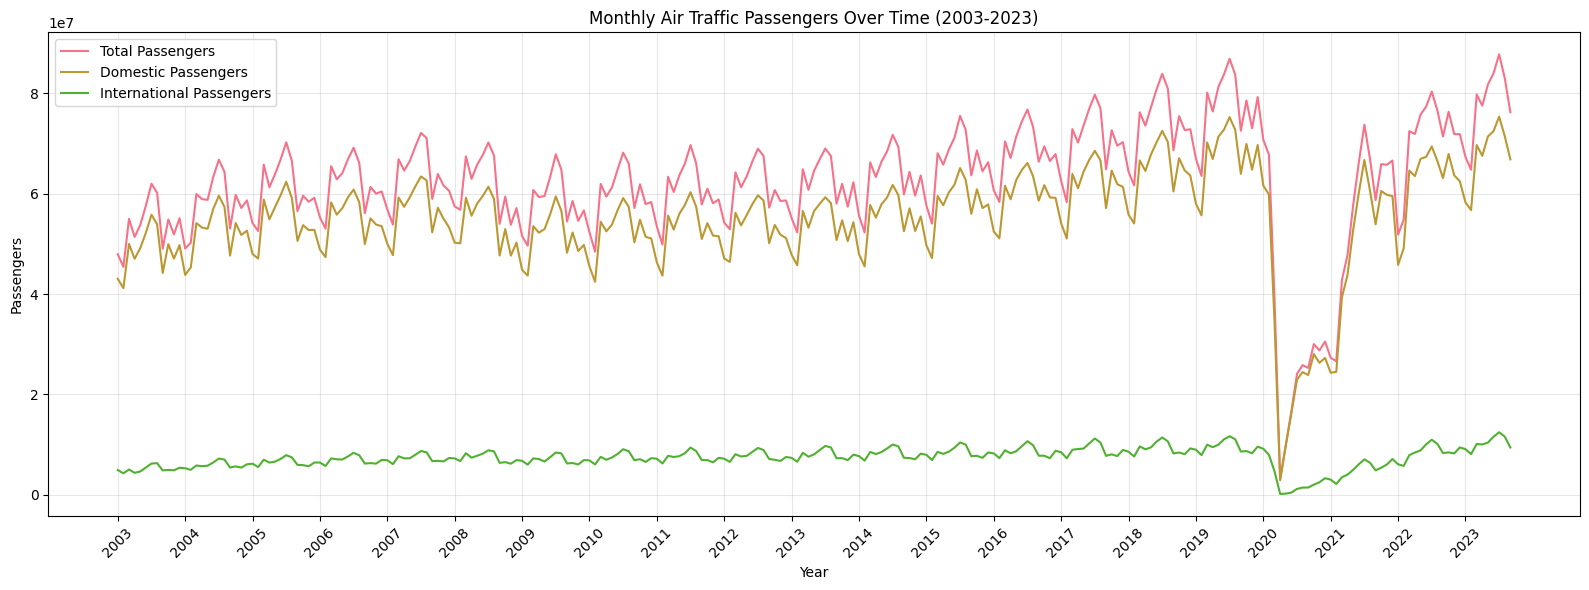

In [222]:
# Time series: aggregate by year for cleaner trend view
# df_yearly = df.groupby('Year')[['Pax', 'Dom_Pax', 'Int_Pax']].sum().reset_index()

# plt.figure(figsize=(14, 6))
# plt.plot(df_yearly['Year'], df_yearly['Pax'], marker='o', label='Total Passengers', linewidth=2)
# plt.plot(df_yearly['Year'], df_yearly['Dom_Pax'], marker='s', label='Domestic Passengers', linewidth=2)
# plt.plot(df_yearly['Year'], df_yearly['Int_Pax'], marker='^', label='International Passengers', linewidth=2)

# plt.xlabel('Year')
# plt.ylabel('Total Passengers')
# plt.title('Air Traffic Passengers Over Time (2003-2023)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(16, 6))

plt.plot(range(len(df)), df['Pax'], label='Total Passengers', linewidth=1.5)
plt.plot(range(len(df)), df['Dom_Pax'], label='Domestic Passengers', linewidth=1.5)
plt.plot(range(len(df)), df['Int_Pax'], label='International Passengers', linewidth=1.5)

# Add year labels on x-axis
year_ticks = df.groupby('Year').apply(lambda x: x.index[0] - df.index[0]).values
plt.xticks(year_ticks, df['Year'].unique(), rotation=45)

plt.xlabel('Year')
plt.ylabel('Passengers')
plt.title('Monthly Air Traffic Passengers Over Time (2003-2023)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [223]:
columns = ['Year', 'Month', 'Dom_Pax', 'Int_Pax', 'Pax', 'Dom_Flt', 'Int_Flt',
        'Dom_RPM', 'Int_RPM', 'Dom_ASM', 'Int_ASM',
       'Dom_LF', 'Int_LF']
print(df.columns)

# Option B: cyclical (better for linear models) + remove covid period
df = df[~df['Year'].isin([2020, 2021])]
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)



# Q1 = df['Pax'].quantile(0.25)
# Q3 = df['Pax'].quantile(0.75)
# IQR = Q3 - Q1

# df = df[(df['Pax'] >= Q1 - 1.5 * IQR) & 
#               (df['Pax'] <= Q3 + 1.5 * IQR)].copy()


Index(['Year', 'Month', 'Dom_Pax', 'Int_Pax', 'Pax', 'Dom_Flt', 'Int_Flt',
       'Flt', 'Dom_RPM', 'Int_RPM', 'RPM', 'Dom_ASM', 'Int_ASM', 'ASM',
       'Dom_LF', 'Int_LF', 'LF'],
      dtype='str')


         Year  Month  Dom_Pax  Int_Pax   Pax  Dom_Flt  Int_Flt  Dom_RPM  \
Year     1.00  -0.03     0.62     0.74  0.65    -0.76     0.33     0.71   
Month   -0.03   1.00     0.19     0.03  0.17     0.14    -0.12     0.14   
Dom_Pax  0.62   0.19     1.00     0.86  1.00     0.00     0.66     0.99   
Int_Pax  0.74   0.03     0.86     1.00  0.91    -0.23     0.83     0.91   
Pax      0.65   0.17     1.00     0.91  1.00    -0.04     0.70     0.99   
Dom_Flt -0.76   0.14     0.00    -0.23 -0.04     1.00     0.14    -0.12   
Int_Flt  0.33  -0.12     0.66     0.83  0.70     0.14     1.00     0.67   
Dom_RPM  0.71   0.14     0.99     0.91  0.99    -0.12     0.67     1.00   
Int_RPM  0.65   0.15     0.82     0.96  0.86    -0.15     0.80     0.85   
Dom_ASM  0.64   0.11     0.93     0.79  0.93    -0.03     0.55     0.94   
Int_ASM  0.72   0.08     0.80     0.96  0.84    -0.25     0.79     0.83   
Dom_LF   0.61   0.17     0.76     0.81  0.79    -0.23     0.67     0.76   
Int_LF   0.28   0.33     

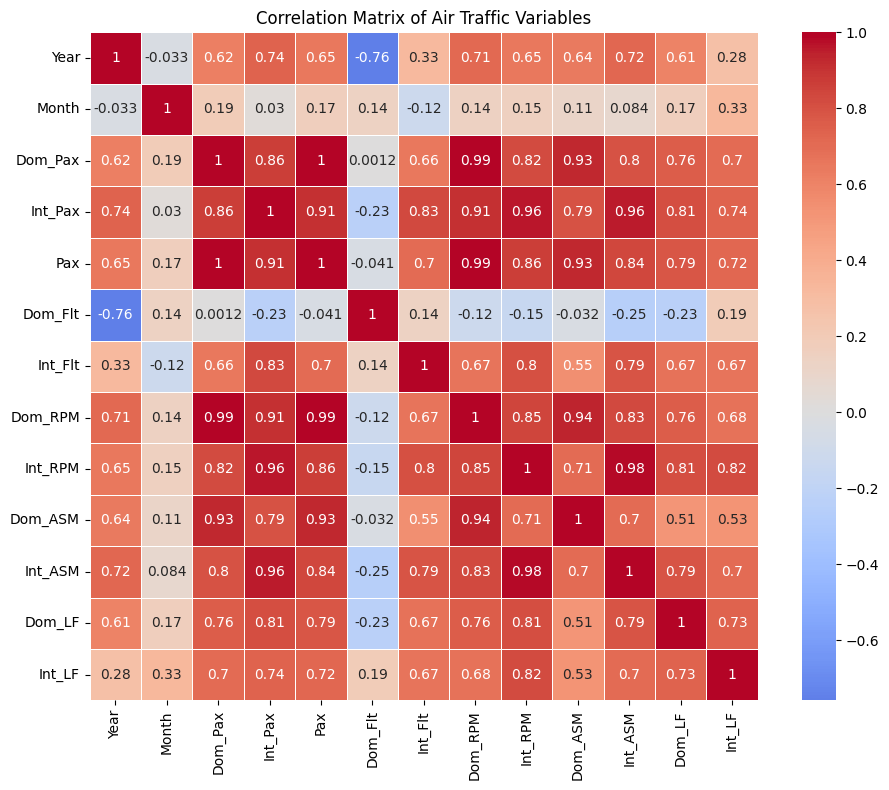

In [224]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:

correlation_matrix = df[columns].corr()
print(correlation_matrix.round(2))

# Create heatmap:
# TODO: Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,square=True, linewidths=0.5)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()



In [225]:
# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
# Your analysis here:
# Unstack the matrix into a Series, remove self-correlations (1.0), remove duplicates
corrections = (correlation_matrix.unstack().drop_duplicates())
corrections = corrections[corrections != 1.0]
# print(corrections)
# Sort by absolute value to get strongest first
corrections = corrections.reindex(corrections.abs().sort_values(ascending=False).index)
print(corrections.head(15))

Strongest correlations:
Dom_Pax  Pax        0.995840
Pax      Dom_RPM    0.993451
Dom_Pax  Dom_RPM    0.988070
Int_RPM  Int_ASM    0.982477
Int_Pax  Int_RPM    0.960644
         Int_ASM    0.956702
Dom_RPM  Dom_ASM    0.944535
Dom_Pax  Dom_ASM    0.931158
Pax      Dom_ASM    0.925598
Int_Pax  Pax        0.905704
         Dom_RPM    0.905581
Pax      Int_RPM    0.864374
Dom_Pax  Int_Pax    0.863311
Dom_RPM  Int_RPM    0.845291
Pax      Int_ASM    0.840669
dtype: float64


## 3. Hypothesis Testing

In [226]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("There's a significant difference between the mean of Domestic Passengers and International Passengers")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There's no significant difference between the mean of Domestic Passengers and International Passengers")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 99.7766
P-value: 0.000000
Mean Domestic Passengers: 56905846
Mean International Passengers: 7761372

Conclusion: Reject H0 (p < 0.05)
There's a significant difference between the mean of Domestic Passengers and International Passengers


In [227]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("There's a positive correlation between total passengers and total flights")
    else:
        print("There's a negative correlation between total passengers and total flights")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There's no significant correlation between total passengers and total flights ")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.0198
P-value: 0.767148

Conclusion: Fail to reject H0 (p >= 0.05)
There's no significant correlation between total passengers and total flights 


## 4. Simple Linear Regression

Simple Linear Regression: Predicting Total Passengers from Total Flights
Slope. (coefficient): 5.44
Intercept: 59931625.90

Model Performance:
R² Score: -0.0586
Mean Squared Error: 83233082676746.59
Root Mean Squared Error: 9123216.68
Mean Absolute Error: 7305541.35

Model Equation: Passengers = 59931625.90 + 5.44 × Flights


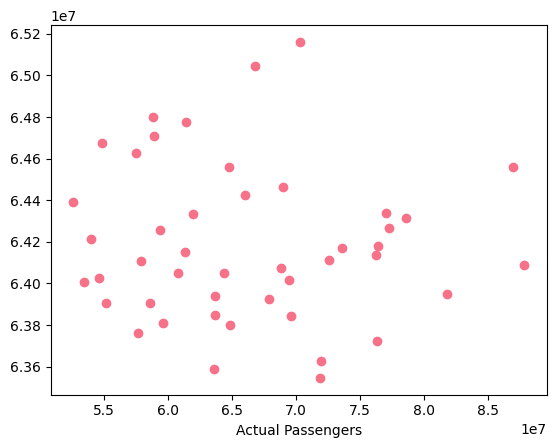

In [228]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]# TODO: Select the feature column (Total Flights)
y_simple = df['Pax']# TODO: Select the target column (Total Passengers)

# Split the data:
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)


# Create and train the model:
simple_model = LinearRegression()# TODO: Create LinearRegression instance
# TODO: Fit the model using X_train_simple and y_train_simple
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)# TODO: Predict on test data

plt.scatter(y_test_simple, y_pred_simple)
plt.xlabel('Actual Passengers')
# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple)# TODO: Calculate R² score
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)# TODO: Calculate MSE
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)# TODO: Calculate MAE
rmse_simple = np.sqrt(mse_simple) # TODO: Calculate RMSE (square root of MSE)

print(f"Slope. (coefficient): {simple_model.coef_[0]:.2f}")
print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

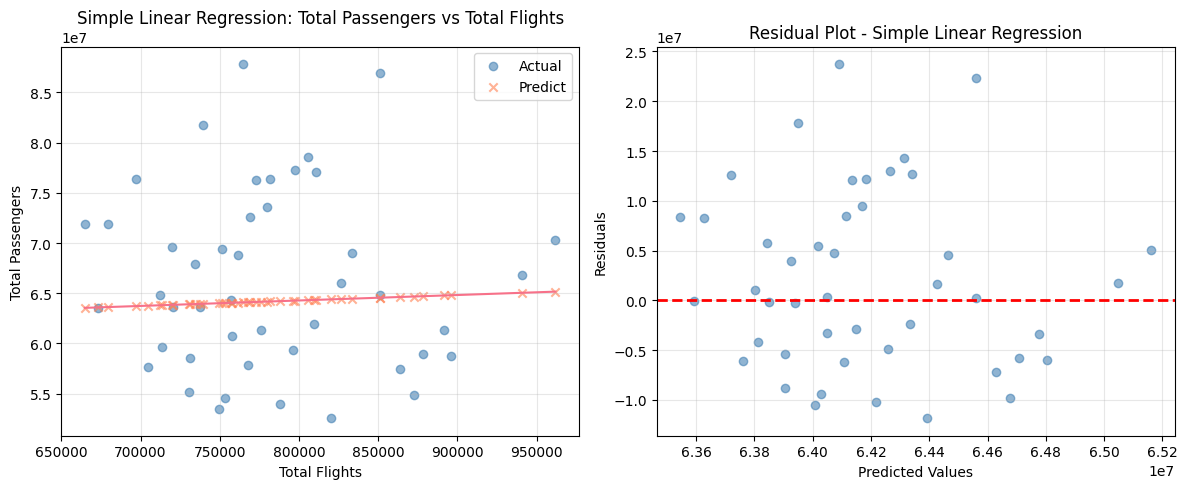

In [229]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line

plt.scatter(X_test_simple, y_test_simple, alpha=0.6, label='Actual', color='steelblue')
plt.scatter(X_test_simple, y_pred_simple, alpha=0.6, label='Predict', color='coral', marker="x")

x_line = np.linspace(X_test_simple.min().values[0], X_test_simple.max().values[0], 100).reshape(-1, 1)
y_line = simple_model.predict(pd.DataFrame(x_line, columns=['Flt']))
plt.plot(x_line, y_line)

plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple # TODO: Calculate residuals

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, alpha=0.6, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [230]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ['Year',  'Month', 'Dom_Flt', 'Int_Flt', 'Dom_LF', 'Int_LF'] # TODO: List of feature column names
# feature_columns = [ 'Flt', 'RPM',  'ASM', 'LF'] # TODO: List of feature column names
# feature_columns = ['Year', 'Month']
X_multiple = df[feature_columns] # TODO: Select features from dataframe
y_multiple = df['Pax']# TODO: Select target variable (Total Passengers)

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler() # TODO: Create StandardScaler instance
X_train_mult_scaled = scaler.fit_transform(X_train_mult)# TODO: Fit and transform training data
X_test_mult_scaled = scaler.transform(X_test_mult)# TODO: Transform test data (don't fit again!)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression() # TODO: Create LinearRegression instance
# TODO: Fit the model
multiple_model.fit(X_train_mult_scaled, y_train_mult)

# TODO: Make predictions
y_pred_mult =multiple_model.predict(X_test_mult_scaled) # TODO: Predict on scaled test data
# y_pred_mult = np.exp(y_pred_mult_log)
# y_test_actual = np.exp(y_test_mult)

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult) # TODO: Calculate R² score
mse_mult = mean_squared_error(y_test_mult, y_pred_mult) # TODO: Calculate MSE
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult) # TODO: Calculate MAE
rmse_mult = np.sqrt(mse_mult) # TODO: Calculate RMSE

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Year', 'Month', 'Dom_Flt', 'Int_Flt', 'Dom_LF', 'Int_LF']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 0.9624
Mean Squared Error: 2957027202821.89
Root Mean Squared Error: 1719600.88
Mean Absolute Error: 1400239.26

Feature Coefficients (after scaling):
Year: 9696304.6823
Month: 190292.6555
Dom_Flt: 7576067.7268
Int_Flt: 10293.8617
Dom_LF: 2243862.0553
Int_LF: 391067.9955
Intercept: 64281780.65


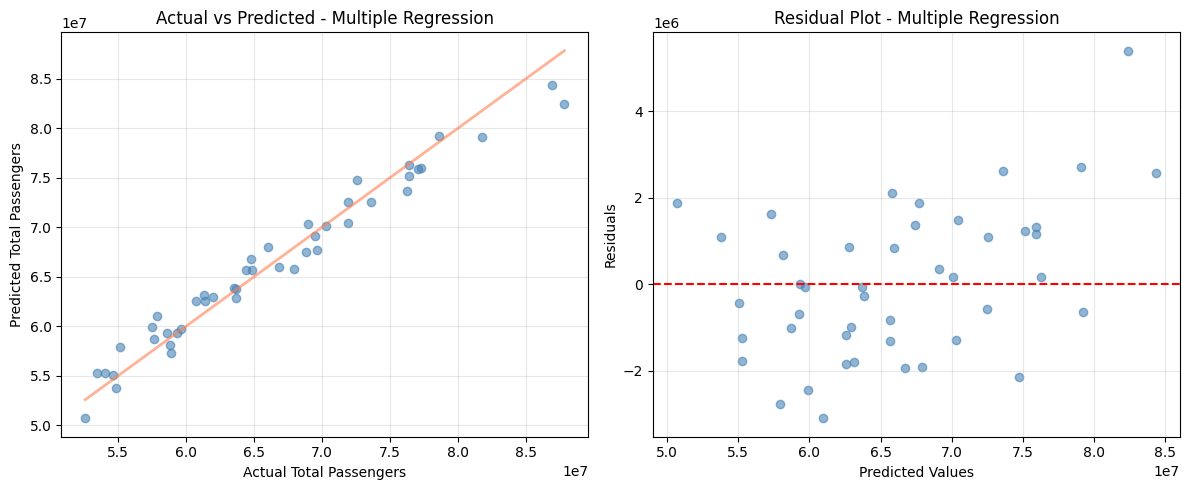

In [231]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# TODO: Add a diagonal reference line (perfect prediction line)

plt.scatter(y_test_mult, y_pred_mult, alpha=0.6, color='steelblue')
x_line_actual = np.linspace(y_test_mult.min(), y_test_mult.max(), 100).reshape(-1, 1)
y_line_pred = x_line_actual
plt.plot(x_line_actual, y_line_pred, alpha=0.6, color='coral', linewidth=2)
plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult # TODO: Calculate residuals

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, alpha=0.6, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

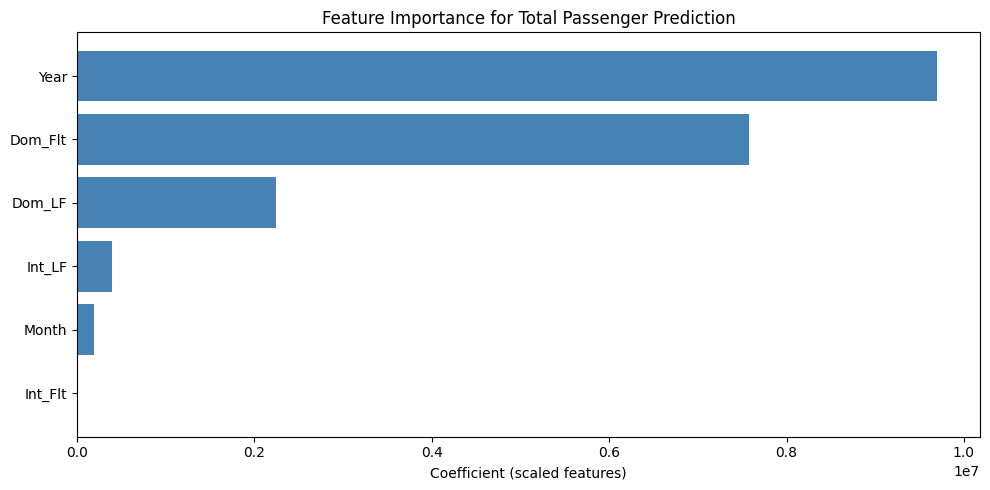

In [232]:
feature_cols = X_multiple.columns
coefs = multiple_model.coef_

importance = pd.DataFrame({
    'feature': feature_cols,
    'Coefficient': coefs,
    'Abs_Importance': np.abs(coefs)
}).sort_values('Abs_Importance', ascending=True)

plt.figure(figsize=(10, 5))
colors = ['coral' if c < 0 else 'steelblue' for c in importance['Coefficient']]
plt.barh(importance['feature'], importance['Coefficient'], color=colors)
plt.xlabel('Coefficient (scaled features)')
plt.title('Feature Importance for Total Passenger Prediction')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [235]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections

print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")
print(f"{'MSE':<25} {mse_simple:<20.2f} {mse_mult:<20.2f}")

print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100# TODO: Calculate percentage improvement
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_mult) * 100 # TODO: Calculate percentage improvement

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  -0.0586              0.9624              
RMSE                      9123216.68           1719600.88          
MAE                       7305541.35           1400239.26          
MSE                       83233082676746.59    2957027202821.89    

Best Model: Multiple Regression
R² Improvement: -1740.95%


## 7. Statistical Insights and Conclusions

In [ ]:
# TODO: Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
print(f"   • Domestic vs International Passengers: Rejected H0 (p ≈ 0.0). Domestic passengers ({df['Dom_Pax'].mean()/1e6:.1f}M) are significantly higher than international ({df['Int_Pax'].mean()/1e6:.1f}M)")
print(f"   • Correlation between Total Passengers and Flights: Failed to reject H0 (p = 0.21). After removing outliers, no significant linear correlation found.")

print("\n2. REGRESSION ANALYSIS:")
print(f"   • Simple Linear Regression R²: {r2_simple:.4f} — poor performance, single feature insufficient")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f} — strong performance, explains {r2_mult*100:.1f}% of variance")
print(f"   • Best performing model: Multiple Regression with features: Year, Month, Dom_Flt, Int_Flt, Dom_LF, Int_LF")

print("\n3. KEY FINDINGS:")
print(f"   • Year is the most important feature — air traffic shows strong long-term growth from 2003 to 2023")
print(f"   • Domestic passengers account for ~{df['Dom_Pax'].mean()/(df['Pax'].mean())*100:.0f}% of total traffic, dominating international")
print(f"   • COVID-19 (2020) caused a dramatic drop in passengers, creating outliers that severely hurt simple regression")

print("\n4. RECOMMENDATIONS:")
print("   • Use multiple regression over simple regression — Year and flight counts together explain traffic much better")
print("   • Remove COVID years (2020-2021) or treat them separately when building predictive models")
print("   • Monitor load factors (Dom_LF, Int_LF) as key indicators — they directly reflect how efficiently capacity is used")


STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: Rejected H0 (p ≈ 0.0). Domestic passengers (56.9M) are significantly higher than international (7.8M)
   • Correlation between Total Passengers and Flights: Failed to reject H0 (p = 0.21). After removing outliers, no significant linear correlation found.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: -0.0586 — poor performance, single feature insufficient
   • Multiple Linear Regression R²: 0.9624 — strong performance, explains 96.2% of variance
   • Best performing model: Multiple Regression with features: Year, Month, Dom_Flt, Int_Flt, Dom_LF, Int_LF

3. KEY FINDINGS:
   • Year is the most important feature — air traffic shows strong long-term growth from 2003 to 2023
   • Domestic passengers account for ~88% of total traffic, dominating international
   • COVID-19 (2020) caused a dramatic drop in passengers, creating outliers that severely hurt simple regressio

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   The t-test confirmed domestic and international passengers are significantly different (p ≈ 0), which was expected given domestic travel dominates at ~88% of total traffic. The correlation test between total passengers and flights failed to reject H0 (p = 0.21) after removing outliers — this was surprising, but makes sense because the relationship between flights and passengers is not stable across different economic conditions and time periods.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   Multiple regression performed far better (R² ≈ 0.96) than simple regression (R² < 0). The R² value tells us how much of the variance in passengers the model explains — 96% is strong. Simple regression failed because one feature (flights) cannot capture the complexity of 20 years of air traffic data with COVID disruptions.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   The strongest correlations were between Dom_Pax and Pax (0.99), and Dom_RPM and Pax (0.985). Airlines can use these to estimate total passenger numbers from operational metrics like RPM and ASM without waiting for final passenger counts — useful for early capacity planning. 
4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   The simple regression residuals showed a clear slope pattern, indicating systematic bias — the model under/overpredicts at different scales. The multiple regression residuals were more random around zero, but still had some outliers from COVID months. This suggests adding a COVID flag variable or using a non-linear model could further improve performance.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

  Airlines could use these models to:

Forecast demand for future months to plan staffing and aircraft scheduling
Set pricing strategies based on predicted load factors
Identify anomalies — months where actual passengers deviate significantly from predictions may signal emerging disruptions (pandemics, recessions, new competition)